Dataset Shape: (100, 4)
Classes: ['setosa' 'versicolor']

===== GINI DECISION TREE =====
Accuracy: 1.0

Confusion Matrix:
[[10  0]
 [ 0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



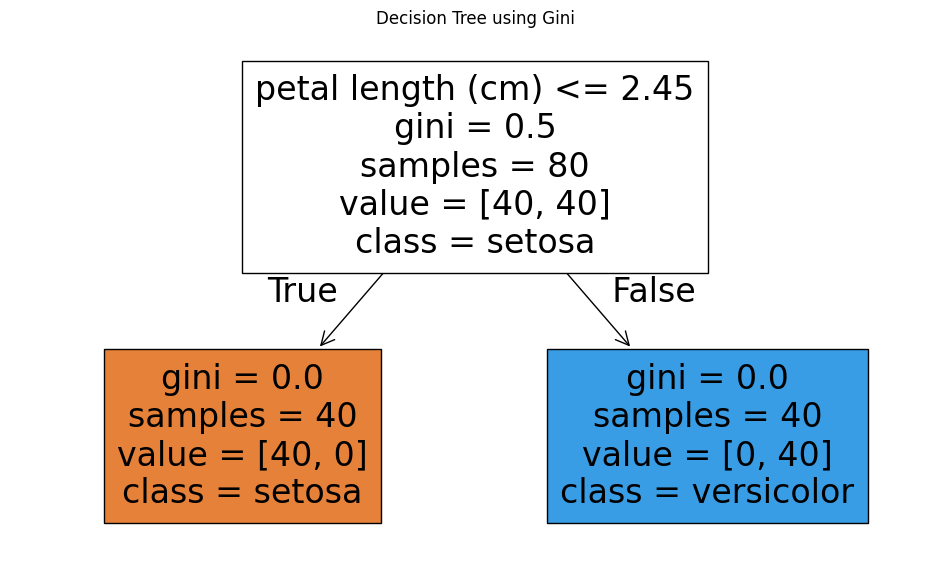


===== ENTROPY DECISION TREE =====
Accuracy: 1.0

Confusion Matrix:
[[10  0]
 [ 0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



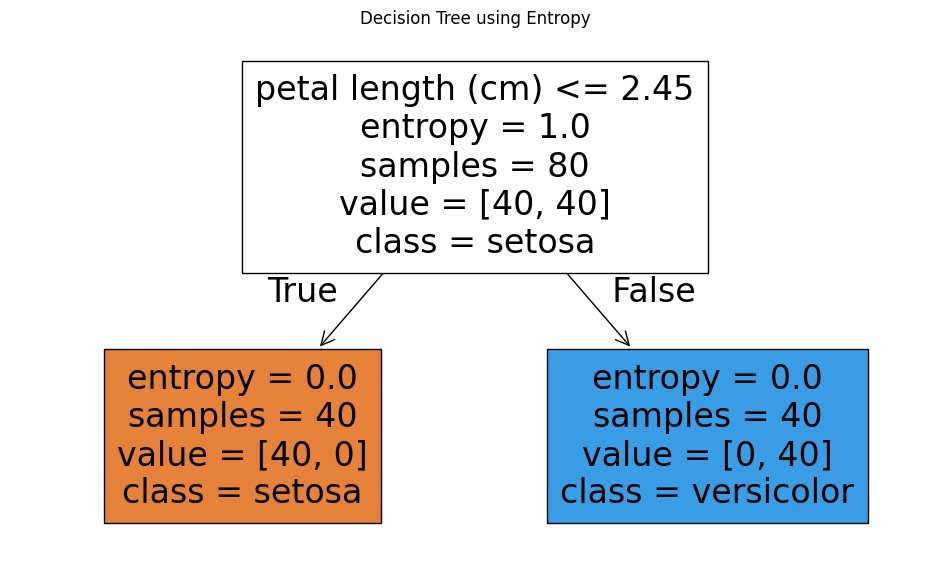


===== GINI vs ENTROPY =====
  Criterion  Accuracy
0      Gini       1.0
1   Entropy       1.0

===== MAX DEPTH RESULTS =====
   Max Depth  Gini Train Accuracy  Gini Test Accuracy  Entropy Train Accuracy  \
0          1                  1.0                 1.0                     1.0   
1          2                  1.0                 1.0                     1.0   
2          3                  1.0                 1.0                     1.0   
3          4                  1.0                 1.0                     1.0   
4          5                  1.0                 1.0                     1.0   
5          6                  1.0                 1.0                     1.0   
6          7                  1.0                 1.0                     1.0   
7          8                  1.0                 1.0                     1.0   
8          9                  1.0                 1.0                     1.0   
9         10                  1.0                 1.0           

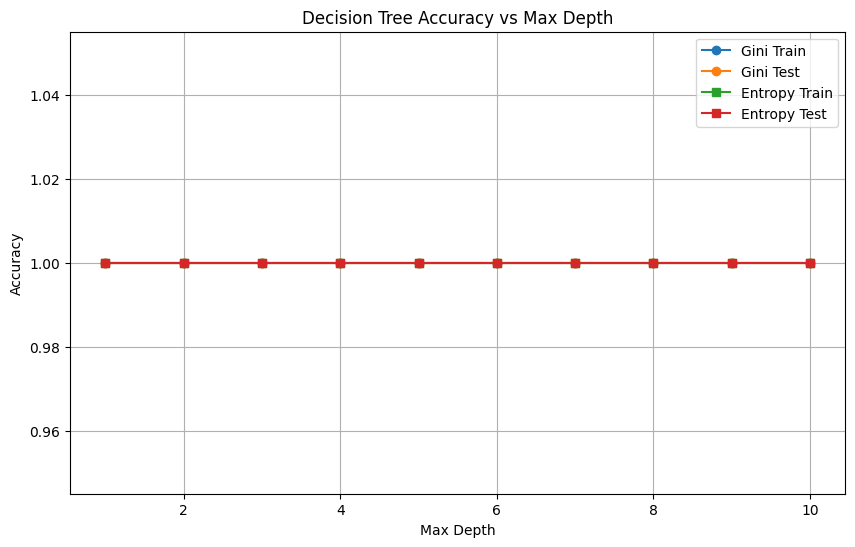

In [1]:
# Decision Tree with depthlimit, etc.. Attributes.
# Decision Tree - Iris Dataset Classification
# Binary Classification
# Gini vs Entropy + Max Depth

# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, plot_tree


# Step 2: Load Iris Dataset
iris = datasets.load_iris()

X = iris.data
y = iris.target

# Binary Classification
# Keep only Setosa (0) and Versicolor (1)
X = X[y != 2]
y = y[y != 2]

print("Dataset Shape:", X.shape)
print("Classes:", iris.target_names[:2])


# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ==========================================================
# Step 4: Decision Tree using Gini
# ==========================================================

gini_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

gini_model.fit(X_train, y_train)

y_pred_gini = gini_model.predict(X_test)

print("\n===== GINI DECISION TREE =====")

print("Accuracy:", accuracy_score(y_test, y_pred_gini))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gini))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_gini,
    target_names=iris.target_names[:2]
))


# Plot Gini Tree
plt.figure(figsize=(12, 7))

plot_tree(
    gini_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names[:2],
    filled=True
)

plt.title("Decision Tree using Gini")
plt.show()


# ==========================================================
# Step 5: Decision Tree using Entropy
# ==========================================================

entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

entropy_model.fit(X_train, y_train)

y_pred_entropy = entropy_model.predict(X_test)

print("\n===== ENTROPY DECISION TREE =====")

print("Accuracy:", accuracy_score(y_test, y_pred_entropy))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_entropy))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_entropy,
    target_names=iris.target_names[:2]
))


# Plot Entropy Tree
plt.figure(figsize=(12, 7))

plot_tree(
    entropy_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names[:2],
    filled=True
)

plt.title("Decision Tree using Entropy")
plt.show()


# ==========================================================
# Step 6: Compare Gini and Entropy
# ==========================================================

gini_accuracy = accuracy_score(y_test, y_pred_gini)
entropy_accuracy = accuracy_score(y_test, y_pred_entropy)

comparison = pd.DataFrame({
    "Criterion": ["Gini", "Entropy"],
    "Accuracy": [gini_accuracy, entropy_accuracy]
})

print("\n===== GINI vs ENTROPY =====")
print(comparison)


# ==========================================================
# Step 7: Effect of Max Depth
# ==========================================================

depth_results = []

for depth in range(1, 11):

    # Gini
    model_gini = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    model_gini.fit(X_train, y_train)

    train_acc_gini = model_gini.score(X_train, y_train)
    test_acc_gini = model_gini.score(X_test, y_test)


    # Entropy
    model_entropy = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=42
    )

    model_entropy.fit(X_train, y_train)

    train_acc_entropy = model_entropy.score(X_train, y_train)
    test_acc_entropy = model_entropy.score(X_test, y_test)


    depth_results.append([
        depth,
        train_acc_gini,
        test_acc_gini,
        train_acc_entropy,
        test_acc_entropy
    ])


depth_df = pd.DataFrame(
    depth_results,
    columns=[
        "Max Depth",
        "Gini Train Accuracy",
        "Gini Test Accuracy",
        "Entropy Train Accuracy",
        "Entropy Test Accuracy"
    ]
)

print("\n===== MAX DEPTH RESULTS =====")
print(depth_df)


# ==========================================================
# Step 8: Plot Accuracy vs Max Depth
# ==========================================================

plt.figure(figsize=(10, 6))

plt.plot(
    depth_df["Max Depth"],
    depth_df["Gini Train Accuracy"],
    marker="o",
    label="Gini Train"
)

plt.plot(
    depth_df["Max Depth"],
    depth_df["Gini Test Accuracy"],
    marker="o",
    label="Gini Test"
)

plt.plot(
    depth_df["Max Depth"],
    depth_df["Entropy Train Accuracy"],
    marker="s",
    label="Entropy Train"
)

plt.plot(
    depth_df["Max Depth"],
    depth_df["Entropy Test Accuracy"],
    marker="s",
    label="Entropy Test"
)

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Max Depth")
plt.legend()
plt.grid(True)
plt.show()